WITHOUT SCALING


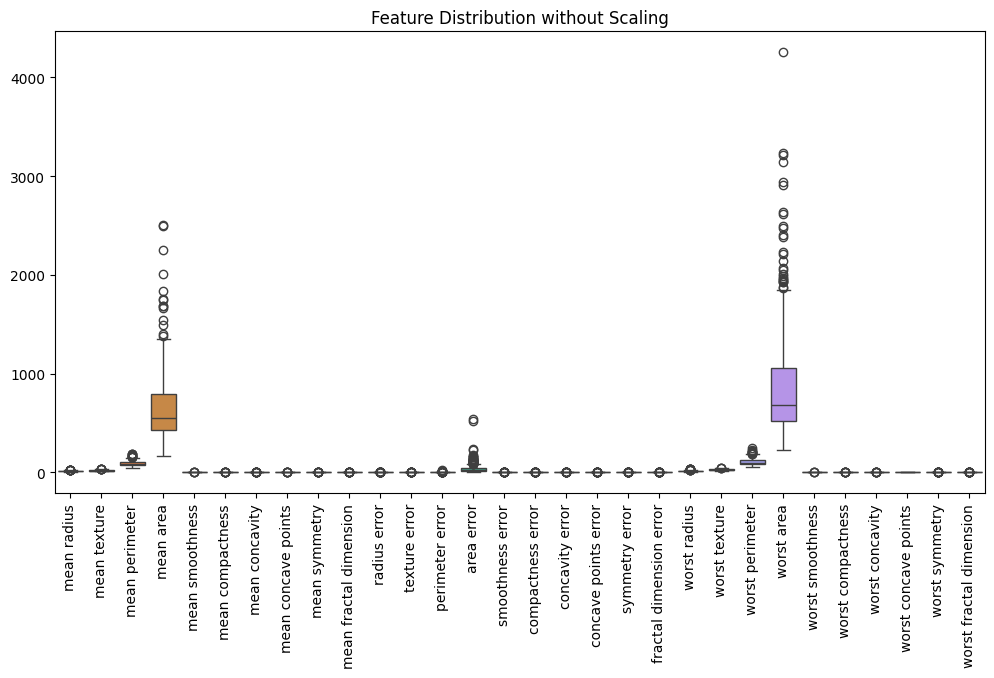


WITHOUT SCALING Accuracy: 0.9766
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171


MIN-MAX SCALING


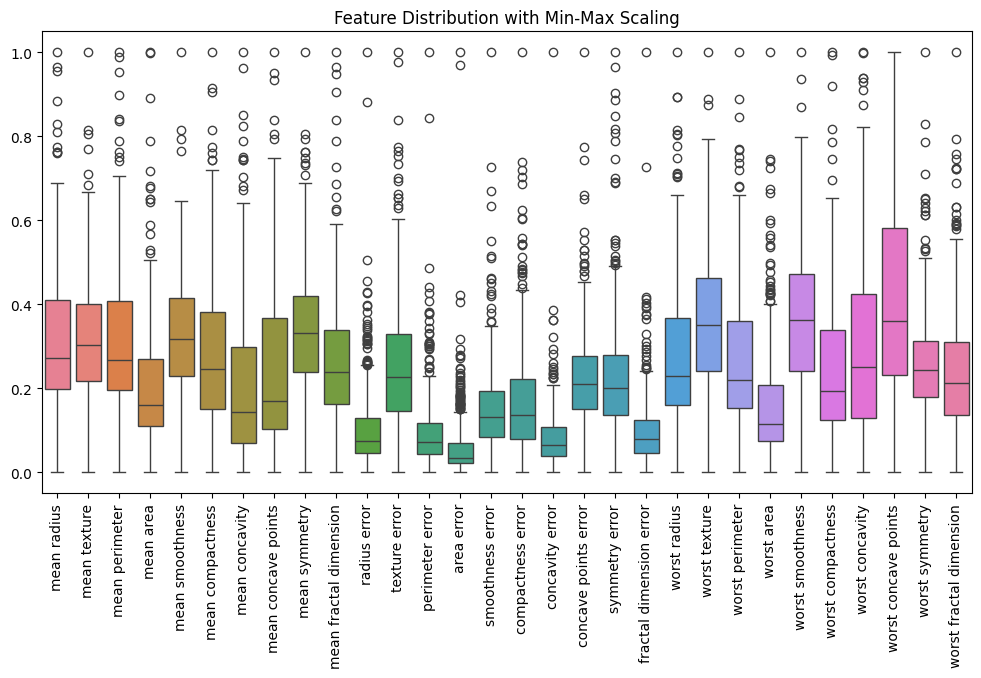


MIN-MAX SCALING Accuracy: 0.9649
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        63
           1       0.96      0.99      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.97      0.96      0.96       171


STANDARD SCALING


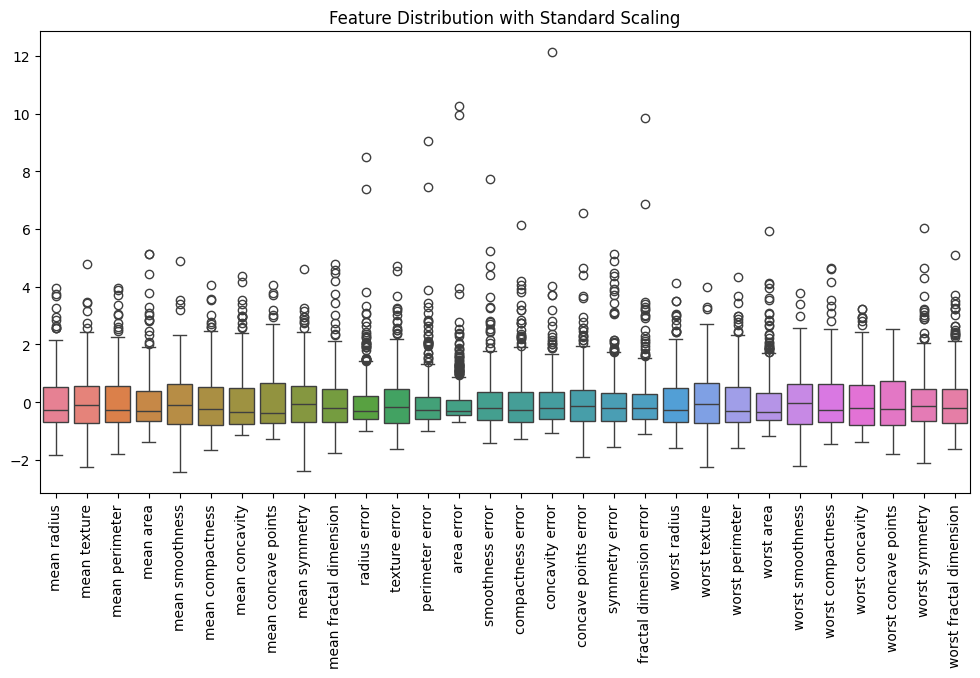


STANDARD SCALING Accuracy: 0.9825
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


ROBUST SCALING


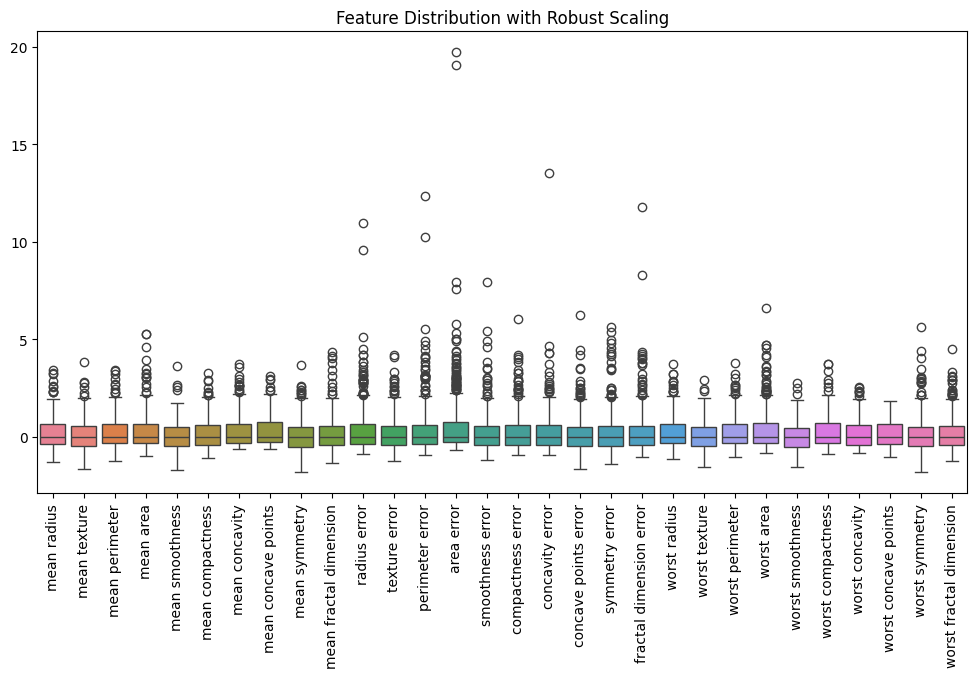


ROBUST SCALING Accuracy: 0.9883
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        63
           1       0.99      0.99      0.99       108

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



In [6]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Function to train and evaluate
def train_and_evaluate(X_train, X_test, title):
    model = LogisticRegression(max_iter=10000)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"\n{title} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))

# Function to plot feature distribution
def plot_distribution(X, title):
    plt.figure(figsize=(12,6))
    sns.boxplot(data=X)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

# 1. Without Scaling
print("WITHOUT SCALING")
plot_distribution(X_train, "Feature Distribution without Scaling")
train_and_evaluate(X_train, X_test, "WITHOUT SCALING")

# 2. Min-Max Scaling
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

print("\nMIN-MAX SCALING")
plot_distribution(pd.DataFrame(X_train_minmax, columns=X.columns), "Feature Distribution with Min-Max Scaling")
train_and_evaluate(X_train_minmax, X_test_minmax, "MIN-MAX SCALING")

# 3. Standard Scaling
scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_train)
X_test_standard = scaler_standard.transform(X_test)

print("\nSTANDARD SCALING")
plot_distribution(pd.DataFrame(X_train_standard, columns=X.columns), "Feature Distribution with Standard Scaling")
train_and_evaluate(X_train_standard, X_test_standard, "STANDARD SCALING")

# 4. Robust Scaling
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_test_robust = scaler_robust.transform(X_test)

print("\nROBUST SCALING")
plot_distribution(pd.DataFrame(X_train_robust, columns=X.columns), "Feature Distribution with Robust Scaling")
train_and_evaluate(X_train_robust, X_test_robust, "ROBUST SCALING")
